In [1]:
# Native libraries
import os
import math
import csv
# Essential Libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates
import numpy as np
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
# Algorithms
#from minisom import MiniSom
from tslearn.barycenters import dtw_barycenter_averaging
from tslearn.clustering import TimeSeriesKMeans
from sklearn.cluster import KMeans
import cartopy.crs as ccrs
import cartopy
import susi
from sklearn.model_selection import GridSearchCV
import xarray as xr
from scipy.stats import kendalltau
from scipy import stats
from sklearn.decomposition import PCA

from datetime import datetime


/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/clustering/kmeans.py:17: UserWarning: Scikit-learn <0.24 will be deprecated in a future release of tslearn
  "Scikit-learn <0.24 will be deprecated in a "


In [2]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)

metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

# define alpha and numeric season order
seasons_a = ['fall','winter','spring','summer']
seasons_n = [3,6,9,12]

# load flow data into dataframe
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/50plus_all_sites.csv')
flow_df.Date = pd.to_datetime(flow_df.Date)
flow_df.set_index('Date', inplace=True)

colors = ['red','blue','green','yellow']

FileNotFoundError: [Errno 2] File /nesi/project/niwa00015/queenle/data/flows/daily/50yrs/50plus_all_sites.csv does not exist: '/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/50plus_all_sites.csv'

In [58]:
metadata_df



,Name,FID,NZREACH,area_km2,gauge_NZTME,gauge_NZTMN,gauge_lat,gauge_lon,centroid_NZ_map_grid_E,centroid_NZ_map_grid_N,centroid_lat,centroid_lon,cat3
Number,,,,,,,,,,,,,
1316,Awanui at School Cut,4194.0,1004260,222.000000,1624354,6114008,-35.12,173.27,2545239.59,6672452.22,-35.148793,173.377644,13
3506,Maungaparerua at Tyrees Ford,6572.0,1006650,11.100000,1680463,6100567,-35.23,173.88,2589021.91,6663273.20,-35.227995,173.859171,35
3722,Waitangi at Wakelins,7543.0,1007625,302.000000,1695269,6095808,-35.28,174.05,2595352.58,6651882.85,-35.329977,173.930204,37
5528,Raumanga at Bernard St,18488.0,1018618,16.299999,1718793,6044861,-35.73,174.31,2625982.12,6605363.31,-35.745377,174.274930,55
6501,Tamahunga at Quintals Falls,28713.0,2001237,7.970000,1755672,5978256,-36.33,174.73,2665811.32,6542683.81,-36.303731,174.729086,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043428,Tahunaatara at Ohakuri Rd,68903.0,3032287,210.000000,1868574,5752436,-38.34,176.07,2785536.03,6322089.13,-38.260989,176.147645,434
1043461,Tongariro at Waipakihi,87091.0,3050479,174.000000,1839248,5654951,-39.22,175.77,2755024.84,6216466.07,-39.221348,175.837722,434
1043466,Waihohonu Stm at Desert Rd,87033.0,3050421,88.000000,1836246,5655650,-39.22,175.74,2738980.60,6218131.36,-39.210829,175.651400,434


In [3]:
winter_clusters = {1: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103],
                   2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
                   3: [1316, 3506, 46618, 46651, 4901, 9301],
                   4: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
                       71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
                  }

winter_names = {1: 'East South Island',2: 'Central North Island',3: 'Northland',4:'West South Island'}
                   
summer_clusters = {1: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
                       75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
                   2: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501],
                   3: [1043466, 29224, 29808, 33117, 33347, 36001],
                   4: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
                       33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408]
                  }

summer_names = {1: 'West South Island',2: 'East South Island',3: 'South North Island',4:'North North Island'}

autumn_clusters = {1: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
                       64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
                       73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
                   2: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
                       23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301]
                  }

autumn_names = {1: 'South',2: 'North'}

spring_clusters = {1: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
                       60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
                       71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
                   2: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
                       3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301]
                  }
spring_names = {1: 'West',2: 'East'}


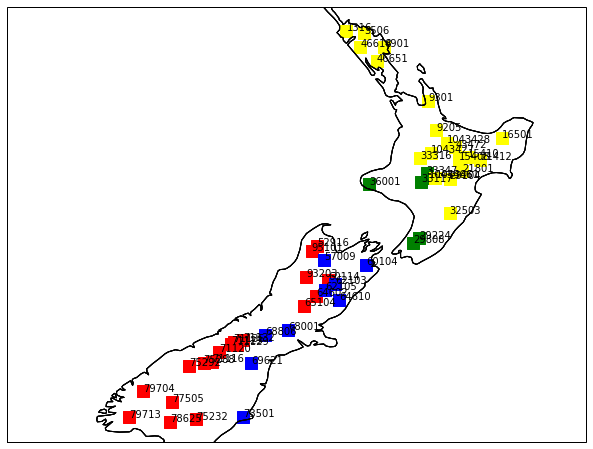

In [4]:
fig, ax = plt.subplots(figsize=(12,8),subplot_kw={'projection': ccrs.PlateCarree()})

for cluster in summer_clusters:
    lons = []
    lats = []
    
    sites = summer_clusters[cluster]
    
    for site in sites:
        lons.append(metadata_df.loc[site]['centroid_lon'])
        lats.append(metadata_df.loc[site]['centroid_lat'])
        
        ax.text(metadata_df.loc[site]['centroid_lon'],metadata_df.loc[site]['centroid_lat'],site)

    
    ax.scatter(lons,lats,c=colors[cluster-1],marker='s',s=150)

    ax.coastlines(resolution='50m', color='black', linewidth=1)
    ax.set_xlim([164,180])
    

In [13]:
def find_centroid_of_timing(water_year):
    
    total_flow = np.sum(water_year.values)
    half_annual_flow = total_flow/2

    #print(half_annual_flow)

    cumulative_flow = 0
    for day in water_year.index:
        cumulative_flow += water_year.loc[day]

        #print(cumulative_flow)

        if cumulative_flow > half_annual_flow:
            #print(day)
            return (datetime('2000',day.month,day.day) - datetime('2000',7,1)).days
            
    return 'didnt find centroid'

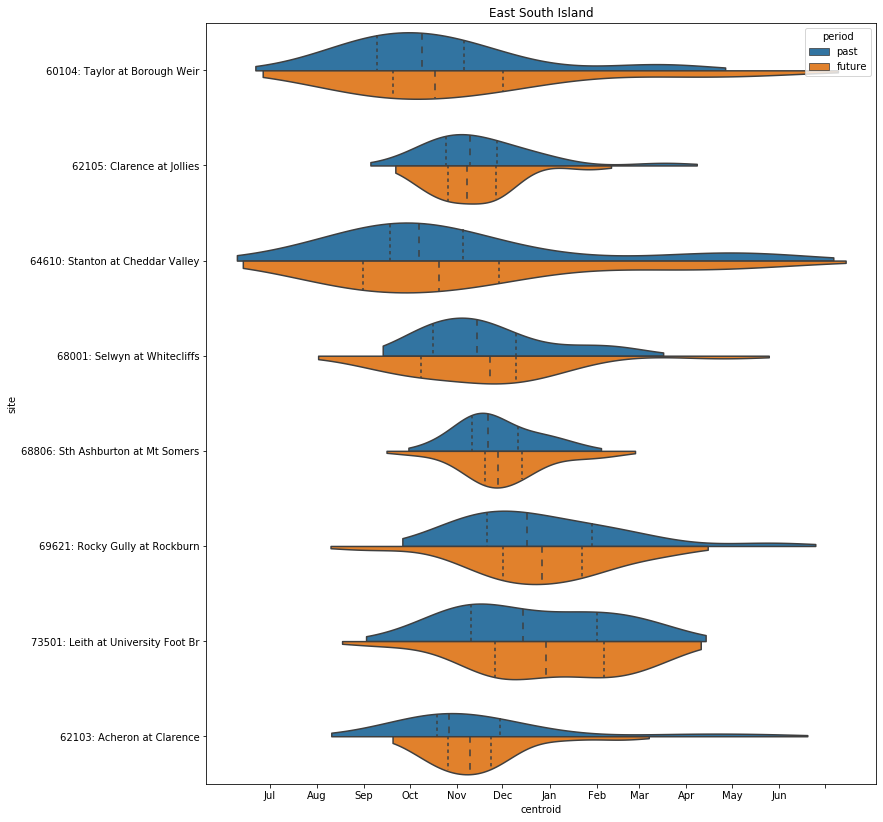

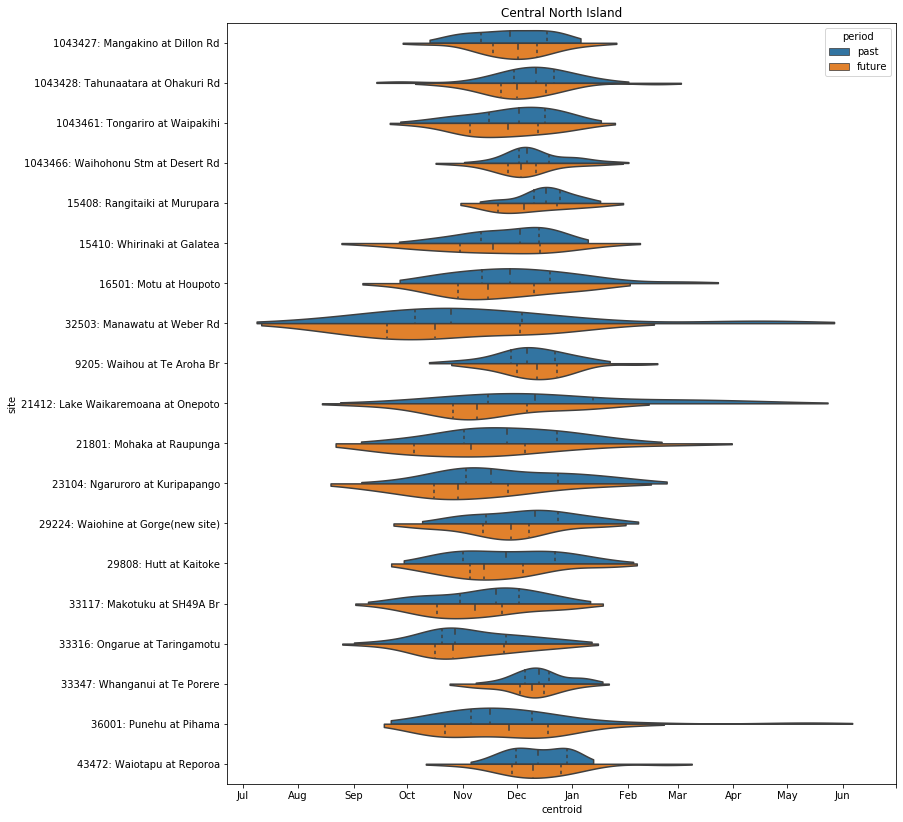

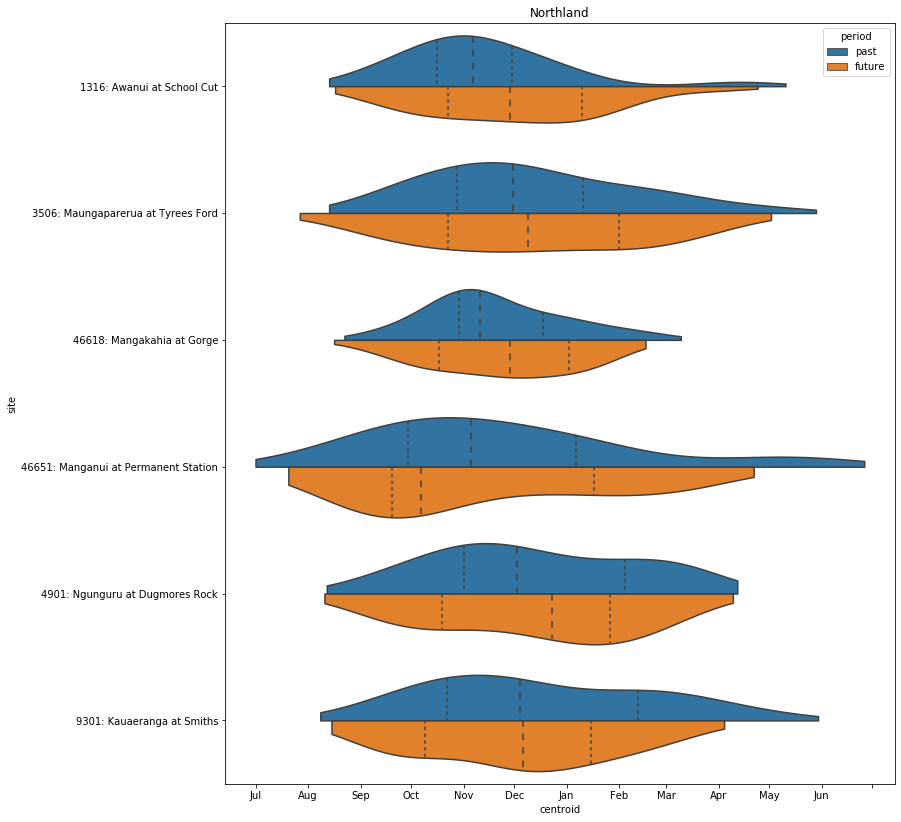

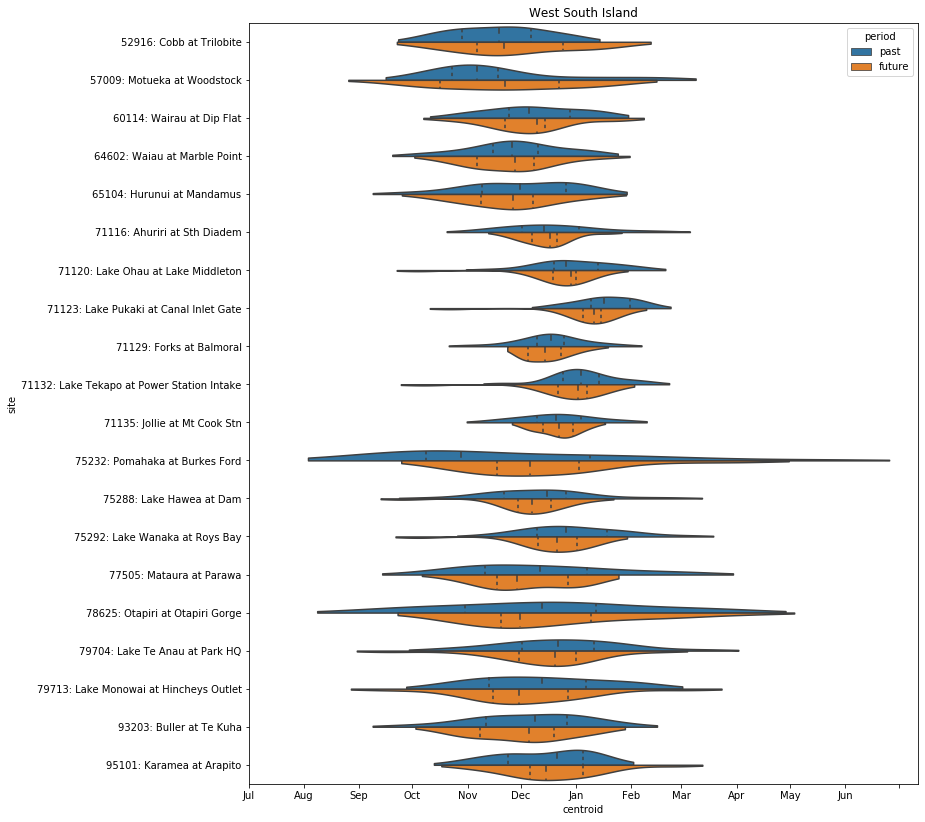

In [7]:


#fig,axs = plt.subplots(2,2,figsize=(12,10))
#axs = axs.flatten()

for cluster in winter_clusters:
    
    fig,axs = plt.subplots(figsize=(12,14))

    cluster_df = flow_df[[str(val) for val in winter_clusters[cluster]]]
    
    sites_dict = {'site':[],'centroid':[],'period':[]}
    for site in cluster_df:
        site_df = cluster_df[site].dropna()
        #site_df = cluster_df[site]
        
        past_centroids = []
            
        #for year in set(site_df.index.year):
        for year in range(1969,1989):
            water_year = site_df.loc[str(year) + '-7-1': str(year+1) +'-6-30']
            #print(water_year)
            
            if len(water_year) == 0:
                centroid = math.nan
            else:
                centroid = find_centroid_of_timing(water_year,year)
            
            if centroid == 'didnt find centroid':
                print(site)
                print(site_df)
                print(water_year)
                break
            
            past_centroids.append(centroid)  
            
            sites_dict['site'].append(site + ": " + metadata_df.loc[int(site)]['Name'])
            sites_dict['centroid'].append(centroid)
            sites_dict['period'].append('past')
            #print(centroids)
            
        future_centroids = []
        for year in range(1999,2019):
            water_year = site_df.loc[str(year) + '-7-1': str(year+1) +'-6-30']
            #print(water_year)
            
            if len(water_year) == 0:
                centroid = math.nan
            else:
                centroid = find_centroid_of_timing(water_year,year)
            
            if centroid == 'didnt find centroid':
                print(site)
                print(site_df)
                print(water_year)
                break
                
            future_centroids.append(centroid)
            
            sites_dict['site'].append(site + ": " + metadata_df.loc[int(site)]['Name'])
            sites_dict['centroid'].append(centroid)
            sites_dict['period'].append('future')
        
    sites_df = pd.DataFrame.from_dict(sites_dict)
        
    #print(sites_df['centroid'].values.tolist())
    sns.violinplot(x='centroid',y='site',hue='period',data=sites_df, ax=axs,split=True,orient='h',cut=1,inner='quartile')
    axs.set_title(winter_names[cluster])
    axs.set_xticks([0,31,62,92,123,153,184,215,243,274,304,335,365])
    axs.set_xticklabels(['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun'])
    

In [60]:
def find_centroid_of_timing(ts):
    
    total_flow = np.sum(ts)
    half_annual_flow = total_flow/2

    #print(half_annual_flow)

    cumulative_flow = 0
    for day in range(len(ts)):
        cumulative_flow += ts[day]

        #print(cumulative_flow)

        if cumulative_flow > half_annual_flow:
            #print(day)
            return (day)
            
    return 'didnt find centroid'

"\nim = axs.scatter(lons,lats,marker='s',s=150,c=vals,cmap='bwr_r')#,vmin=-0.5,vmax=0.5)\naxs.coastlines(resolution='50m', color='black', linewidth=1)\naxs.set_xlim([164,180])\n"

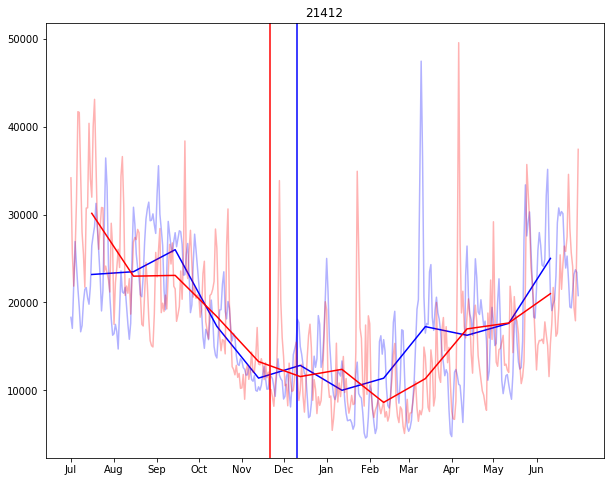

In [91]:

calendar_dict = {0:'Jul',31:'Aug',62:'Sep',92:'Oct',123:'Nov',153:'Dec',184:'Jan',215:'Feb',243:'Mar',274:'Apr',304:'May',335:'Jun'}

lats = []
lons = []
vals = []
for site in ['21412']:#'68806','69621','33117','1043466','1043461','46651','3506','79713','71123','60114','78625']:#winter_clusters[4]:

    site = str(site)
    
    fig, axs = plt.subplots(figsize=(10,8))#,subplot_kw={'projection': ccrs.PlateCarree()})

    site_df = flow_df[site].dropna()
    
    past_df = site_df['1969':'1989']
    present_df = site_df['1999':'2019']

    past_daily_AC = past_df.groupby([past_df.index.month, past_df.index.day]).mean()
    past_monthly_AC = past_df.groupby(past_df.index.month).mean()
    #past_df.index = pd.to_datetime('2000-' + past_df.index.get_level_values(0).astype(str) + '-' + past_df.index.get_level_values(1).astype(str))
    past_WY = past_daily_AC.values.tolist()[182:] + past_daily_AC.values.tolist()[:182]    
    past_centroid = find_centroid_of_timing(past_WY)
    
    axs.plot(past_WY,c='blue',label='past',alpha=0.3)
    axs.plot([30*i+15 for i in range(12)],past_monthly_AC.values.tolist()[6:] + past_monthly_AC.values.tolist()[:6],c='b')
    axs.axvline(past_centroid,c='blue')
    

    present_daily_AC = present_df.groupby([present_df.index.month, present_df.index.day]).mean()
    present_monthly_AC = present_df.groupby(present_df.index.month).mean()

    #present_df.index = pd.to_datetime('2000-' + present_df.index.get_level_values(0).astype(str) + '-' + present_df.index.get_level_values(1).astype(str))   
    present_WY = present_daily_AC.values.tolist()[182:] + present_daily_AC.values.tolist()[:182]
    present_centroid = find_centroid_of_timing(present_WY)    
    
    axs.plot(present_WY,c='r',label='present',alpha=0.3)
    axs.plot([30*i+15 for i in range(12)],present_monthly_AC.values.tolist()[6:] + present_monthly_AC.values.tolist()[:6],c='r')
    axs.axvline(present_centroid,c='r')
    
    
    axs.set_xticks([key for key in calendar_dict])
    axs.set_xticklabels([calendar_dict[key] for key in calendar_dict])
    
    axs.set_title(site)

'''
im = axs.scatter(lons,lats,marker='s',s=150,c=vals,cmap='bwr_r')#,vmin=-0.5,vmax=0.5)
axs.coastlines(resolution='50m', color='black', linewidth=1)
axs.set_xlim([164,180])
'''
#fig.colorbar(im)


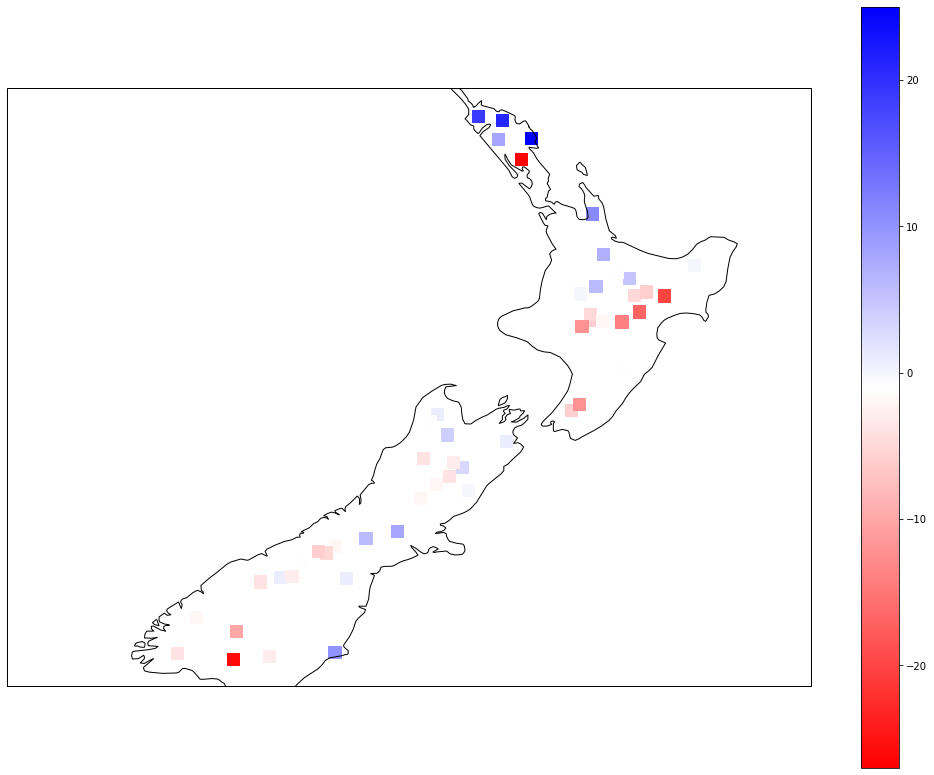

In [85]:
fig, axs = plt.subplots(figsize=(18,14),subplot_kw={'projection': ccrs.PlateCarree()})

#calendar_dict = {0:'Jul',31:'Aug',62:'Sep',92:'Oct',123:'Nov',153:'Dec',184:'Jan',215:'Feb',243:'Mar',274:'Apr',304:'May',335:'Jun'}

lats = []
lons = []
vals = []
for site in flow_df:

    site_df = flow_df[site].dropna()
    past_df = site_df['1969':'1989']
    present_df = site_df['1999':'2019']

    past_df = past_df.groupby([past_df.index.month, past_df.index.day]).mean()
    past_WY = past_df.values.tolist()[182:] + past_df.values.tolist()[:182]    
    past_centroid = find_centroid_of_timing(past_WY)
    
    present_df = present_df.groupby([present_df.index.month, present_df.index.day]).mean()
    present_WY = present_df.values.tolist()[182:] + present_df.values.tolist()[:182]
    present_centroid = find_centroid_of_timing(present_WY)    
    
    centroid_shift = present_centroid - past_centroid
    
    lats.append(metadata_df.loc[int(site)]['centroid_lat'])
    lons.append(metadata_df.loc[int(site)]['centroid_lon'])
    vals.append(centroid_shift)


im = axs.scatter(lons,lats,marker='s',s=150,c=vals,cmap='bwr_r')#,vmin=-0.5,vmax=0.5)
axs.coastlines(resolution='50m', color='black', linewidth=1)
axs.set_xlim([164,180])

fig.colorbar(im)


In [7]:
import re


f = open("../tindex_1981-2010_to_Dec2019.txt")
lines = f.readlines()

dfs = []
for label in ['  Z1','  M1']:
    df_dict = {}
    for line in lines:
        if line[:4] == label:
            year = line[6:10]
            values = line[12:-7]        
            values_split = re.findall('....',values)
            
            for i in range(12):
                month = i+1
                val = float(values_split[i])
                date = str(year) + '-' + str(month) + '-15'

                df_dict[date] = val

    df = pd.DataFrame.from_dict(df_dict,orient='index',columns = [label[2:]])
    df.index = pd.to_datetime(df.index)
    dfs.append(df)
    
monthly_trenberth = pd.concat(dfs, axis=1)
monthly_trenberth.replace(999.0, math.nan,inplace=True)
normed_trenberth = (monthly_trenberth - monthly_trenberth.mean()) / monthly_trenberth.std()

AC_trenberth = normed_trenberth.groupby(normed_trenberth.index.month).mean()

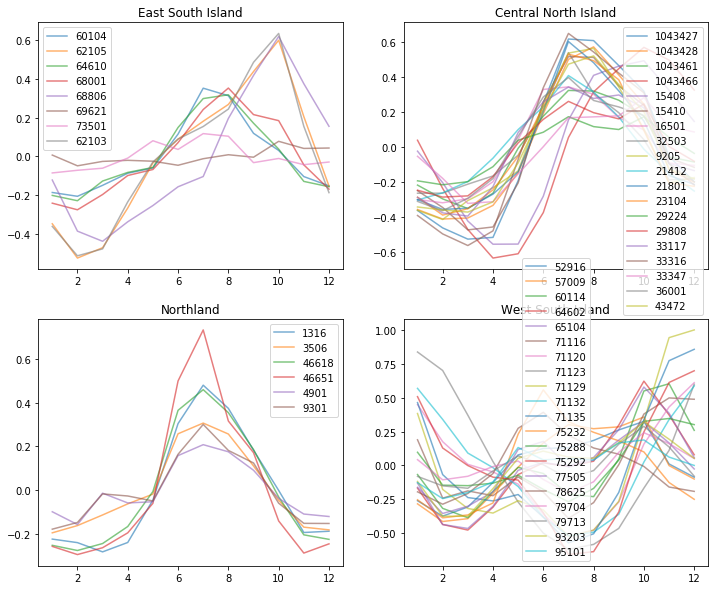

In [81]:
anom = (flow_df - flow_df.mean()) / flow_df.std()

fig,axs = plt.subplots(2,2,figsize=(12,10))
axs = axs.flatten()

for cluster in winter_clusters:
    cluster_df = anom[[str(val) for val in winter_clusters[cluster]]]
    
    for site in cluster_df:
        
        annual_cycle = cluster_df[site].groupby(cluster_df[site].index.month).mean()
        axs[cluster-1].plot(annual_cycle,alpha=0.6,label=site)
        
        
    axs[cluster-1].set_title(winter_names[cluster])
    #axs[cluster-1].plot(AC_trenberth['Z1'],label='Z1')
    #axs[cluster-1].plot(AC_trenberth['M1'],label='M1')

    axs[cluster-1].legend()

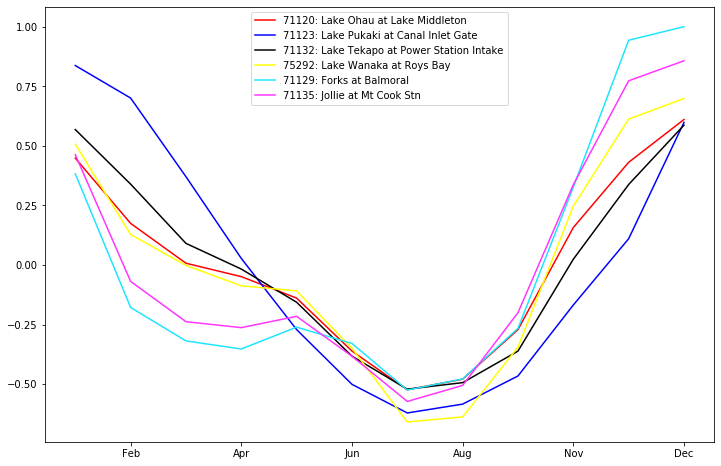

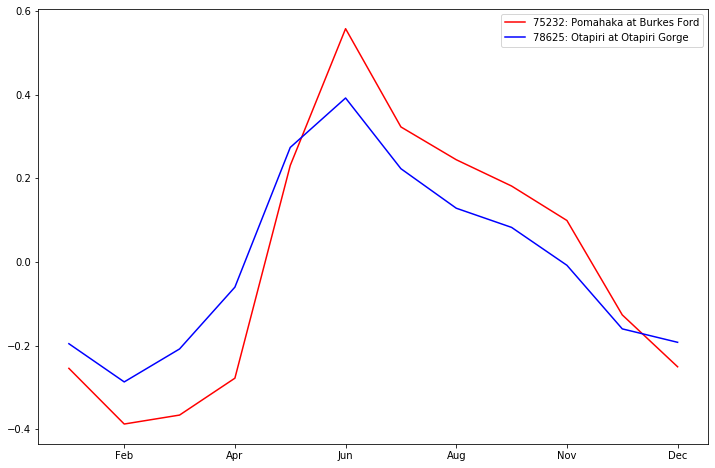

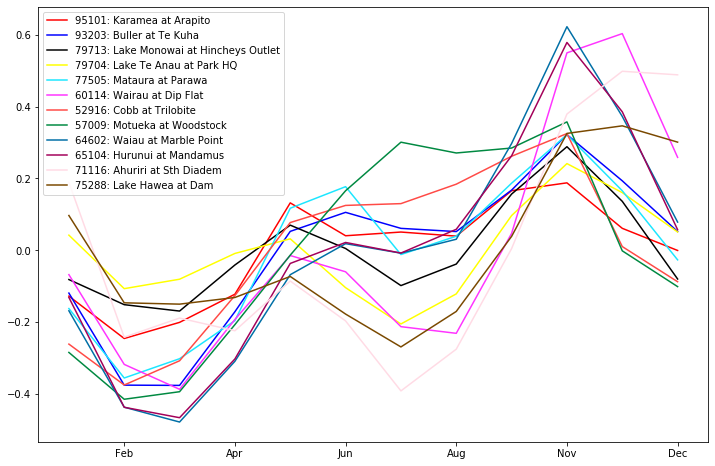

In [13]:
anom = (flow_df - flow_df.mean()) / flow_df.std()

#fig,axs = plt.subplots(1,1,figsize=(12,10))

for cluster in winter_clusters:
    if winter_names[cluster] != 'West South Island':
        continue
        
    cluster_df = anom[[str(val) for val in winter_clusters[cluster]]]
    
    #71135, , 75288, , , , , , ]

    p1 = ['71120','71123','71132','75292','71129','71135']
    p2 = ['75232','78625']
    p3 = ['95101','93203','79713','79704','77505','60114','52916','57009','64602','65104','71116','75288']
    
    
    for p in [p1,p2,p3]:
        
        fig,axs = plt.subplots(1,1,figsize=(12,8))
        
        for i,site in enumerate(p):
            annual_cycle = cluster_df[site].groupby(cluster_df[site].index.month).mean()
            axs.plot(annual_cycle,c=colors[i],label=site + ': ' + str(metadata_df.loc[int(site)]['Name']))
            #axs.plot(annual_cycle,c=colors[i],label=site)

        axs.legend()
        axs.set_xticks([2,4,6,8,10,12],)
        axs.set_xticklabels(['Feb','Apr','Jun','Aug','Nov','Dec'])

In [11]:
colors = ['r','b',"#000000", "#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
"#FFDBE5", "#7A4900", "#0000A6", "#63FFAC", "#B79762", "#004D43", "#8FB0FF", "#997D87",
"#5A0007", "#809693", "#FEFFE6", "#1B4400", "#4FC601", "#3B5DFF", "#4A3B53", "#FF2F80",
"#61615A", "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9", "#B903AA", "#D16100"]

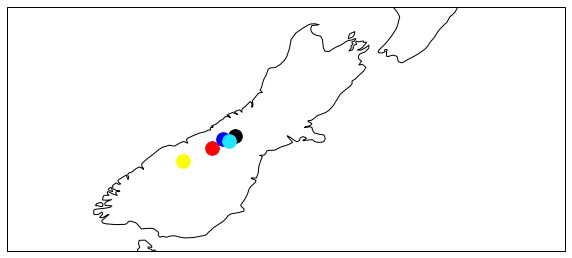

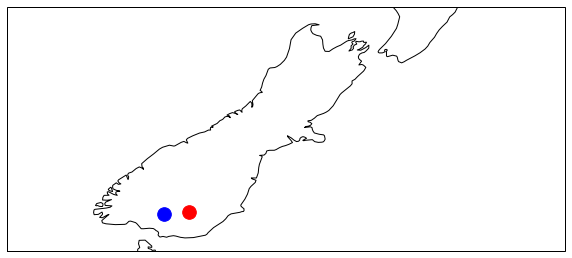

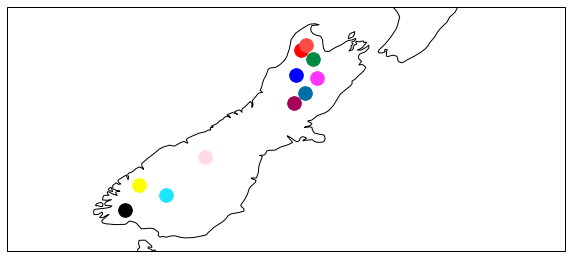

In [48]:
for cluster in winter_clusters:
    if winter_names[cluster] != 'West South Island':
        continue
        
    
    cluster_df = anom[[str(val) for val in winter_clusters[cluster]]]
    
    p1 = ['71120','71123','71132','75292','71129']
    p2 = ['75232','78625']
    p3 = ['95101','93203','79713','79704','77505','60114','52916','57009','64602','65104','71116']
    
    
    for p in [p1,p2,p3]:
        
        fig,axs = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection': ccrs.PlateCarree()})
        
        for i,site in enumerate(p):

            lon = metadata_df.loc[int(site)]['centroid_lon']
            lat = metadata_df.loc[int(site)]['centroid_lat']

            axs.scatter(lon,lat,marker='o',s=185,c=colors[i])

        axs.coastlines(resolution='50m', color='black',linewidth=1)
        axs.set_xlim([164,180])
        axs.set_ylim([-47,-40])

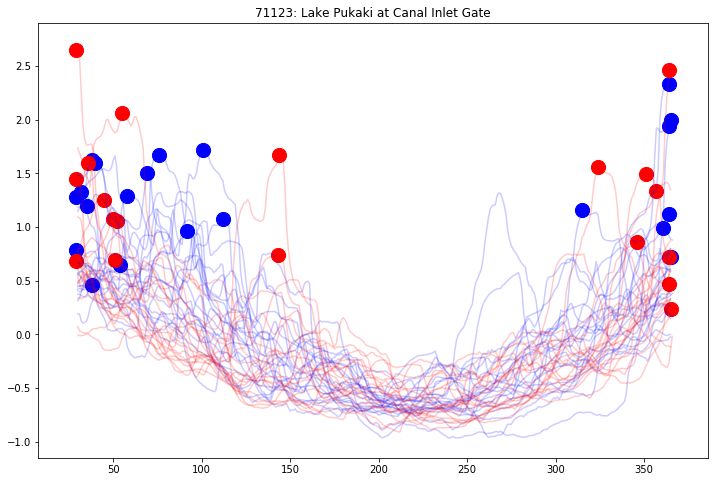

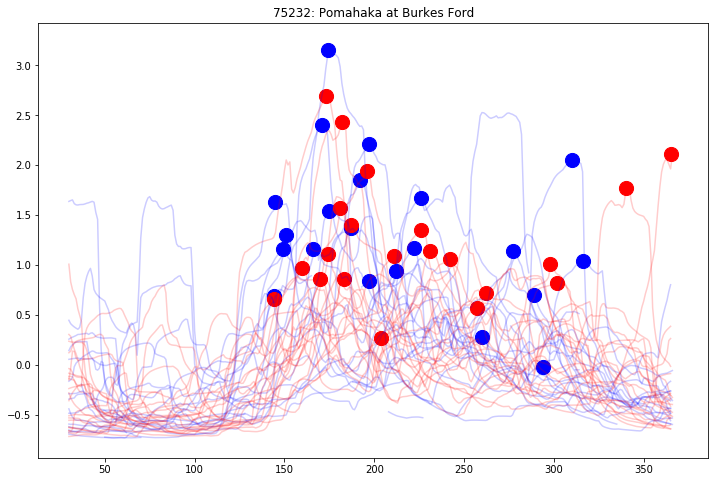

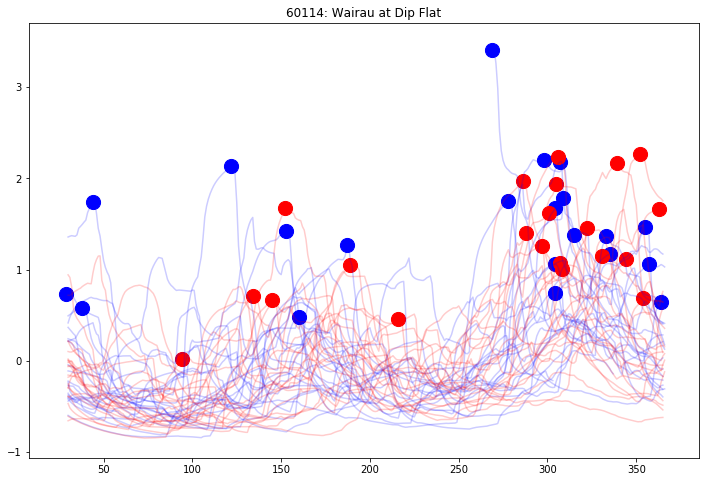

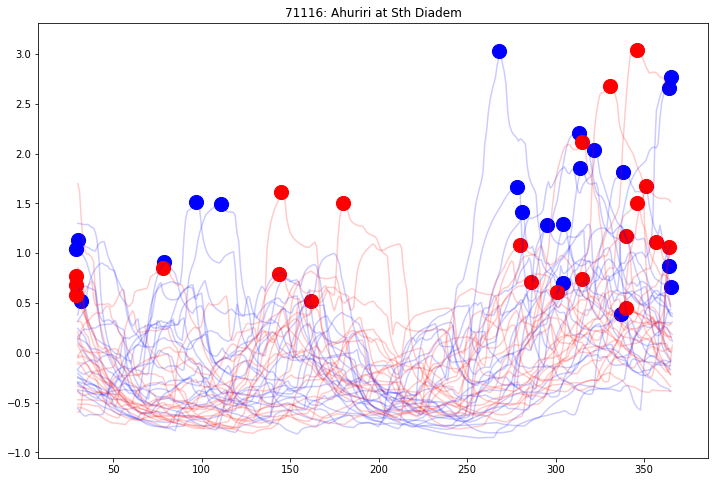

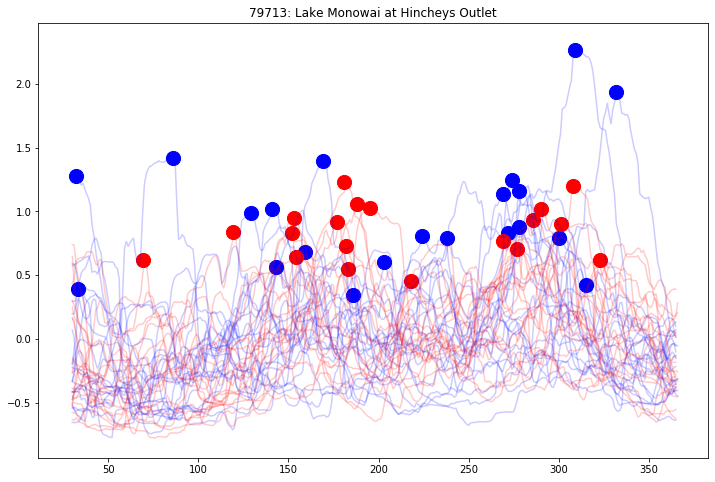

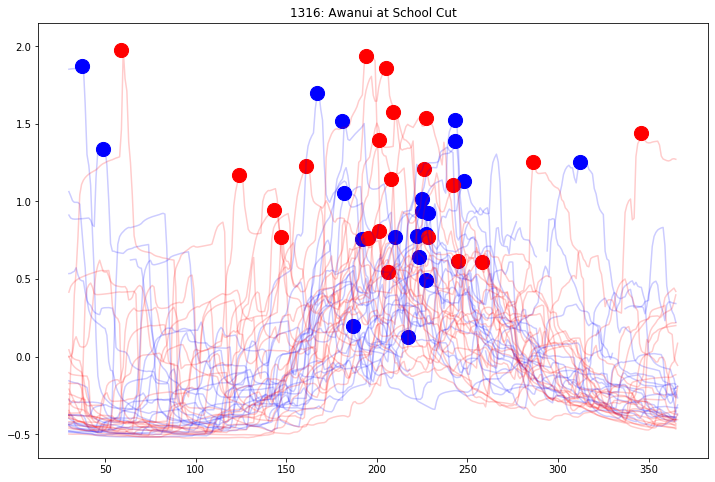

In [119]:
# find distribution of timing of annual peak for representative locations in Northland and W South Island

locations = ['71123','75232','60114','71116','79713','1316']

anom = (flow_df - flow_df.mean()) / flow_df.std()

for site in locations:
    
    df = anom[site]

    fig,axs = plt.subplots(1,1,figsize=(12,8))

    for yr in np.unique(df.index.year.values):
        
        if yr >=1969 and yr <= 1989:
            color = 'blue'
        elif yr >= 1999 and yr <=2019:
            color = 'red'
        else:
            continue
        
        year = df.loc[str(yr)]
        
        if len(year) < 100:
            continue
        
        running_mean = year.rolling(window=30).mean()
        if np.isnan(running_mean).all():
            continue

        #plt.plot([i for i in range(len(year))],year)
        plt.plot([i+1 for i in range(len(running_mean))],running_mean,c=color,alpha=0.2)
        
        values = running_mean.values
        index = np.nanargmax(values)
        val = values[index]
        
        plt.scatter(index,val,c=color,s=200)
        plt.title(site + ': ' +str(metadata_df.loc[int(site)]['Name']))
        #annual_cycle = cluster_df[site].groupby(cluster_df[site].index.month).mean()



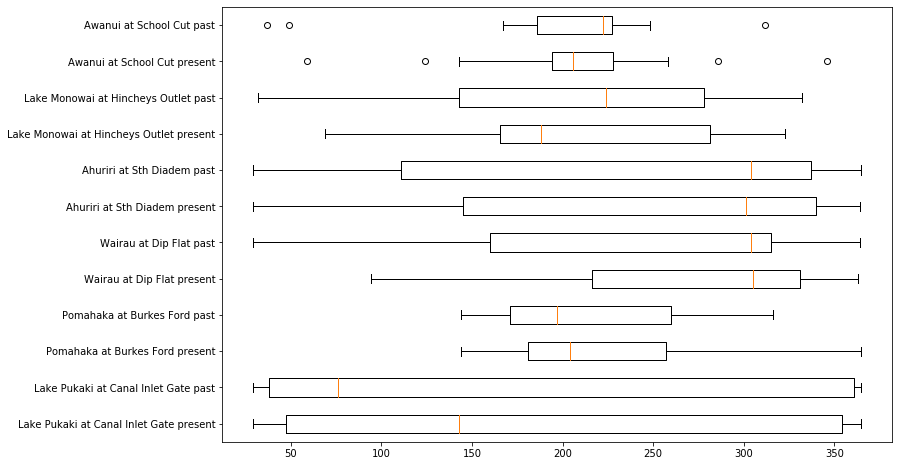

In [125]:
# find distribution of timing of annual peak for representative locations in Northland and W South Island

fig,axs = plt.subplots(1,1,figsize=(12,8))

locations = ['71123','75232','60114','71116','79713','1316']

anom = (flow_df - flow_df.mean()) / flow_df.std()

site_dists = []
labels = []
for site in locations:
    
    df = anom[site]


    past_peaks = []
    present_peaks = []
    for yr in np.unique(df.index.year.values):
    
        year = df.loc[str(yr)]
        
        if len(year) < 100:
            continue
        
        running_mean = year.rolling(window=30).mean()
        
        if np.isnan(running_mean).all():
            continue

        values = running_mean.values
        index = np.nanargmax(values)
        val = values[index]
        
        if yr >=1969 and yr <= 1989:
            past_peaks.append(index)
        elif yr >= 1999 and yr <=2019:
            present_peaks.append(index)
        else:
            continue
                
    site_dists.append(present_peaks)
    labels.append(metadata_df.loc[int(site)]['Name'] + ' present')
    site_dists.append(past_peaks)
    labels.append(metadata_df.loc[int(site)]['Name'] + ' past')

    
plt.boxplot(site_dists, positions=[i for i in range(len(labels))], labels=labels, vert=False)
plt.show()


[Text(0, 0, 'Jul'),
 Text(0, 0, 'Aug'),
 Text(0, 0, 'Sep'),
 Text(0, 0, 'Oct'),
 Text(0, 0, 'Nov'),
 Text(0, 0, 'Dec'),
 Text(0, 0, 'Jan'),
 Text(0, 0, 'Feb'),
 Text(0, 0, 'Mar'),
 Text(0, 0, 'Apr'),
 Text(0, 0, 'May'),
 Text(0, 0, 'Jun')]

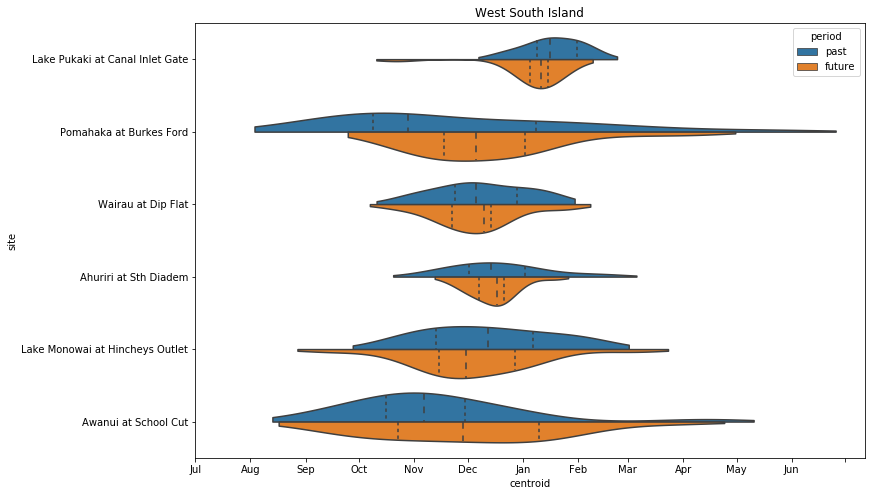

In [124]:
from datetime import datetime

fig,axs = plt.subplots(figsize=(12,8))

locations = ['71123','75232','60114','71116','79713','1316']

sites_dict = {'site':[],'centroid':[],'period':[]}
for site in locations:
    site_df = flow_df[site].dropna()

    past_centroids = []

    for year in range(1969,1989):
        water_year = site_df.loc[str(year) + '-7-1': str(year+1) +'-6-30']

        if len(water_year) == 0:
            centroid = math.nan
        else:
            centroid = find_centroid_of_timing(water_year,year)

        if centroid == 'didnt find centroid':
            print(site)
            print(site_df)
            print(water_year)
            break

        past_centroids.append(centroid)  

        sites_dict['site'].append(metadata_df.loc[int(site)]['Name'])
        sites_dict['centroid'].append(centroid)
        sites_dict['period'].append('past')
        #print(centroids)

    future_centroids = []
    for year in range(1999,2019):
        water_year = site_df.loc[str(year) + '-7-1': str(year+1) +'-6-30']
        #print(water_year)

        if len(water_year) == 0:
            centroid = math.nan
        else:
            centroid = find_centroid_of_timing(water_year,year)

        if centroid == 'didnt find centroid':
            print(site)
            print(site_df)
            print(water_year)
            break

        future_centroids.append(centroid)

        sites_dict['site'].append(metadata_df.loc[int(site)]['Name'])
        sites_dict['centroid'].append(centroid)
        sites_dict['period'].append('future')

sites_df = pd.DataFrame.from_dict(sites_dict)

#print(sites_df['centroid'].values.tolist())
sns.violinplot(x='centroid',y='site',hue='period',data=sites_df, ax=axs,split=True,orient='h',cut=1,inner='quartile')
axs.set_title(winter_names[cluster])
axs.set_xticks([0,31,62,92,123,153,184,215,243,274,304,335,365])
axs.set_xticklabels(['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun'])
